# StayPredict — 04. Model Evaluation & Explainability
Evaluating serialized production model performance, residual diagnostics, and tree-based feature importance.


In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)

# Load serialized model and test data
model = joblib.load("../models/best_model.joblib")
metadata = joblib.load("../models/model_metadata.joblib")
data = joblib.load("../data/processed/split_data.joblib")

X_test_processed = data['X_test_processed']
y_test = data['y_test']
feature_names = data['feature_names']

print("--- PRODUCTION ARTIFACTS VERIFIED ---")
print(f"Loaded Model:      {metadata['model_name']} (v{metadata['model_version']})")
print(f"Trained Date:      {metadata['trained_date']}")
print(f"X_test samples:    {X_test_processed.shape[0]:,} rows, {X_test_processed.shape[1]} features")


--- PRODUCTION ARTIFACTS VERIFIED ---
Loaded Model:      StayPredict Random Forest Regressor (v1.0.0)
Trained Date:      2026-10-04 13:11:03
X_test samples:    10,994 rows, 29 features


In [2]:
# Generate predictions on the test set
y_pred = model.predict(X_test_processed)
residuals = y_test - y_pred

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- INDEPENDENT TEST METRIC VERIFICATION ---")
print(f"Mean Absolute Error (MAE): {mae:.4f} days")
print(f"Root Mean Squared Error:   {rmse:.4f} days")
print(f"R² Score:                  {r2:.4f}")
print(f"Mean Residual (Bias):      {residuals.mean():.4f} days (near 0 confirms unbiased model)")


--- INDEPENDENT TEST METRIC VERIFICATION ---
Mean Absolute Error (MAE): 7.4747 days
Root Mean Squared Error:   8.6282 days
R² Score:                  0.0089
Mean Residual (Bias):      0.0048 days (near 0 confirms unbiased model)


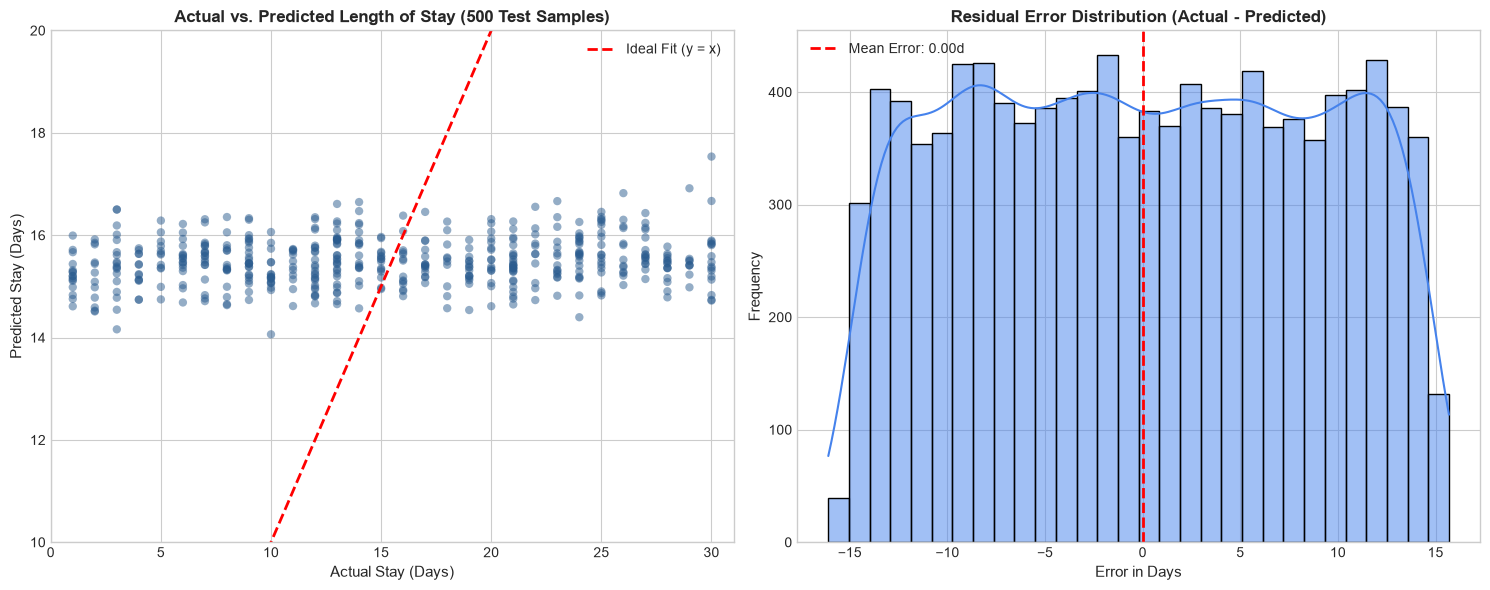

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Actual vs Predicted (Subsample of 500 points for clarity)
sample_idx = np.random.choice(len(y_test), size=500, replace=False)
axes[0].scatter(y_test.iloc[sample_idx], y_pred[sample_idx], alpha=0.5, color='#2b5c8f', edgecolors='none')
axes[0].plot([1, 30], [1, 30], 'r--', linewidth=2, label="Ideal Fit (y = x)")
axes[0].set_title("Actual vs. Predicted Length of Stay (500 Test Samples)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Actual Stay (Days)", fontsize=11)
axes[0].set_ylabel("Predicted Stay (Days)", fontsize=11)
axes[0].set_xlim(0, 31)
axes[0].set_ylim(10, 20)
axes[0].legend()

# Plot 2: Residual Distribution
sns.histplot(residuals, bins=30, kde=True, ax=axes[1], color='#4582ec')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label=f"Mean Error: {residuals.mean():.2f}d")
axes[1].set_title("Residual Error Distribution (Actual - Predicted)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Error in Days", fontsize=11)
axes[1].set_ylabel("Frequency", fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()


--- TOP 15 MOST INFLUENTIAL FEATURES ---


,Feature,Importance
0,Age,0.177548
1,Admission Day,0.154492
2,Admission Month,0.114908
3,Admission Day of Week,0.092360
4,Admission Year,0.080079
5,Admission Type_Elective,0.021361
6,Admission Type_Emergency,0.021268
7,Gender_Male,0.021016
8,Gender_Female,0.020573
9,Admission Type_Urgent,0.020507


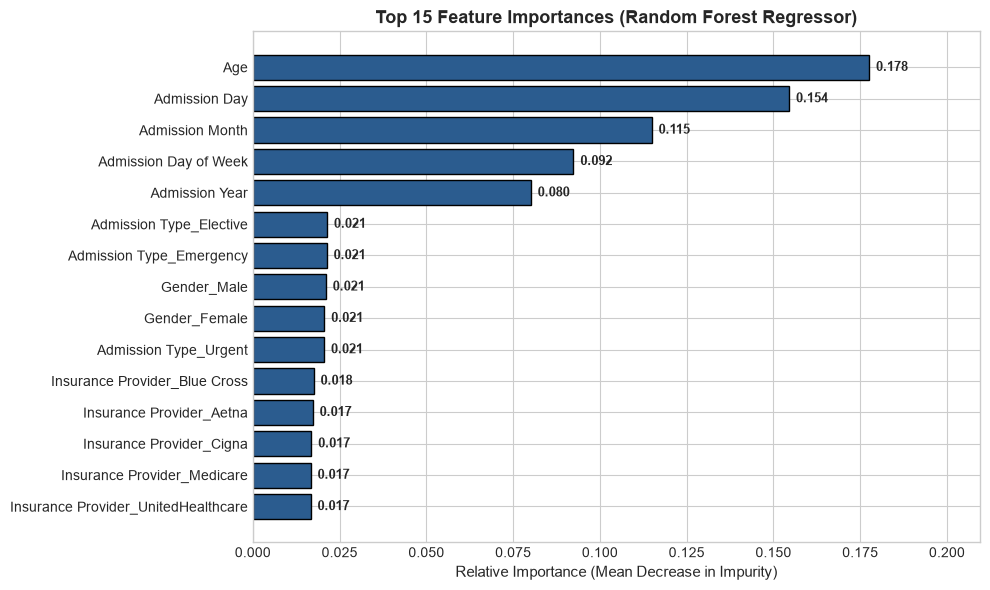

In [4]:
# Extract Mean Decrease in Impurity (MDI) feature importances
importances = model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("--- TOP 15 MOST INFLUENTIAL FEATURES ---")
display(importance_df.head(15))

# Plot Top 15 Feature Importances
plt.figure(figsize=(10, 6))
top_15 = importance_df.head(15).sort_values(by='Importance', ascending=True)
bars = plt.barh(top_15['Feature'], top_15['Importance'], color='#2b5c8f', edgecolor='black')

plt.title("Top 15 Feature Importances (Random Forest Regressor)", fontsize=13, fontweight='bold')
plt.xlabel("Relative Importance (Mean Decrease in Impurity)", fontsize=11)

for bar in bars:
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, 
             f"{bar.get_width():.3f}", va='center', fontsize=9, fontweight='bold')

plt.xlim(0, max(top_15['Importance']) * 1.18)
plt.tight_layout()
plt.show()
